# Directed Graphs and BPMN for MOSFRA / MOWFRA Parts (grouped by PBB_FAMILY)

Loads every CSV file matching `MO*FRA*.csv` in `data/villach/`, groups rows by
`PBB_FAMILY`, and discovers a **directed graph** and **BPMN model** for each group.

- **Case identifier** = `ROUTE` (same role as `ROUTEID` in notebook 04)
- **Event / activity** = `OPERATION`

In [13]:
import os
import pandas as pd
import pm4py
from pathlib import Path

# Ensure Graphviz is on PATH for this session
gviz_bin = r"C:\Program Files\Graphviz\bin"
if gviz_bin not in os.environ["PATH"]:
    os.environ["PATH"] = gviz_bin + os.pathsep + os.environ["PATH"]

DATA_DIR = Path("../../data/villach")

# fra_files = sorted(DATA_DIR.glob("MO*FRA*.csv"))
fra_files = sorted(DATA_DIR.glob("20260721_backside_processes.csv"))
fra_files

[WindowsPath('../../data/villach/20260721_backside_processes.csv')]

## Read and concatenate all CSVs

In [14]:
frames = []
for f in fra_files:
    first_line = open(f, encoding="utf-8-sig").readline().strip()
    if first_line.startswith("sep="):
        sep = first_line.split("=", 1)[1]
        skip = 1
    else:
        sep = ";" if ";" in first_line else ","
        skip = 0

    df = pd.read_csv(f, sep=sep, dtype=str, skiprows=skip).fillna("")
    df["_source_file"] = f.stem
    frames.append(df)
    print(f"  {f.name}: {len(df)} rows")

raw = pd.concat(frames, ignore_index=True)

# Drop rows where PBB_FAMILY is empty or whitespace
raw = raw[raw["PBB_FAMILY"].str.strip() != ""]

print(f"\nTotal: {len(raw)} rows from {len(fra_files)} files")
print(f"PBB_FAMILY values: {sorted(raw['PBB_FAMILY'].unique())}")

  20260721_backside_processes.csv: 2744 rows

Total: 1438 rows from 1 files
PBB_FAMILY values: ['BACKSIDE_IMPLANT', 'GC_DEMOUNT', 'GC_MOUNT', 'GRINDING', 'LOGISTICS', 'SPUTTER_METAL_BACKSIDE', 'TAIKO_GRINDING']


## Build event logs per PBB_FAMILY

Each `PBB_FAMILY` becomes a separate event log:
- `case:concept:name` = ROUTE
- `concept:name` = OPERATION
- `time:timestamp` = synthetic (same convention as notebook 04)

In [15]:
KEEP_COLS = ["ROUTERELATION", "FACILITY", "ROUTEID", "ROUTE",
             "ROUTEDESCRIPTION", "ROUTEOPERORDER", "OPERATION", "PBB_FAMILY"]

logs = {}
for family, group in raw.groupby("PBB_FAMILY"):
    df = group[KEEP_COLS].drop_duplicates().copy()
    df["ROUTEOPERORDER"] = pd.to_numeric(df["ROUTEOPERORDER"], errors="coerce").fillna(0).astype(int)
    df = df.sort_values(["ROUTE", "ROUTEOPERORDER"]).reset_index(drop=True)

    step_per_route = df.groupby("ROUTE").cumcount()
    df["time:timestamp"] = pd.Timestamp("2024-01-01") + pd.to_timedelta(step_per_route * 2 + 8, unit="h")

    df["case:concept:name"] = df["ROUTE"]
    df["concept:name"] = df["OPERATION"]

    events = df[["case:concept:name", "concept:name", "time:timestamp",
                 "ROUTEOPERORDER", "ROUTERELATION", "FACILITY",
                 "ROUTE", "ROUTEDESCRIPTION"]].copy()

    log = pm4py.convert_to_event_log(events)
    logs[family] = log
    n_routes = df["ROUTE"].nunique()
    print(f"  {family}: {n_routes} routes, {len(events)} events")

  BACKSIDE_IMPLANT: 23 routes, 29 events
  GC_DEMOUNT: 17 routes, 51 events
  GC_MOUNT: 23 routes, 143 events
  GRINDING: 6 routes, 48 events
  LOGISTICS: 23 routes, 103 events
  SPUTTER_METAL_BACKSIDE: 23 routes, 69 events
  TAIKO_GRINDING: 17 routes, 153 events


## Discover and display directed graph and BPMN


  BACKSIDE_IMPLANT  (23 traces)


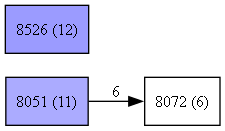

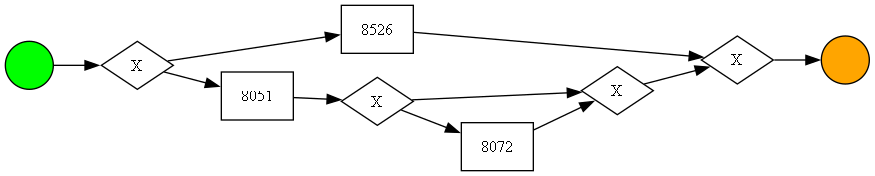


  GC_DEMOUNT  (17 traces)


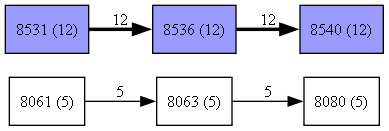

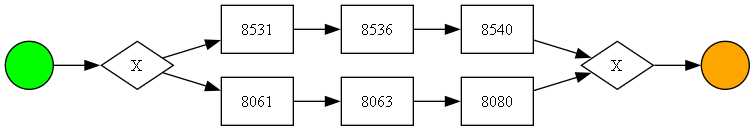


  GC_MOUNT  (23 traces)


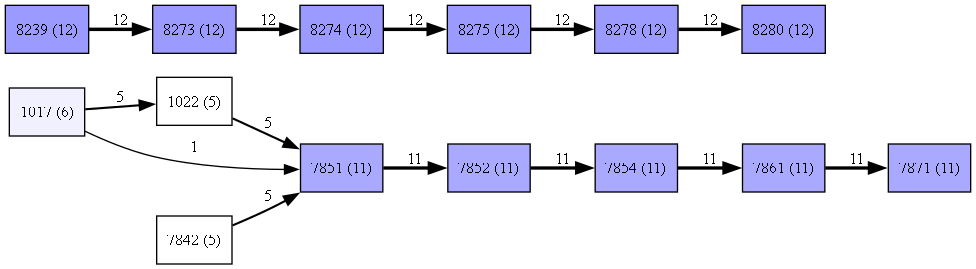

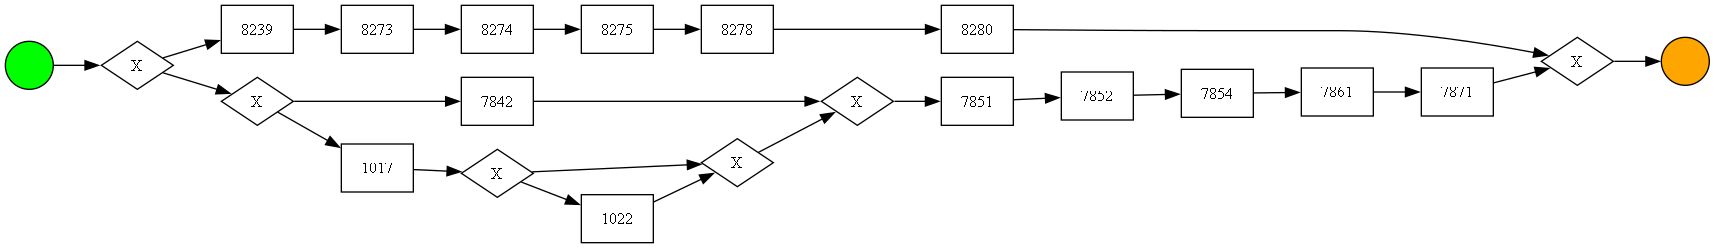


  GRINDING  (6 traces)


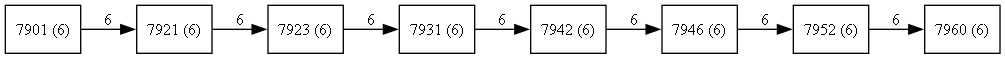

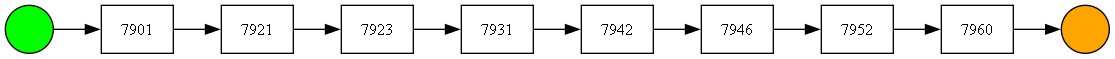


  LOGISTICS  (23 traces)


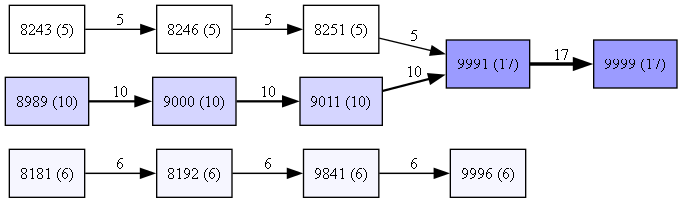

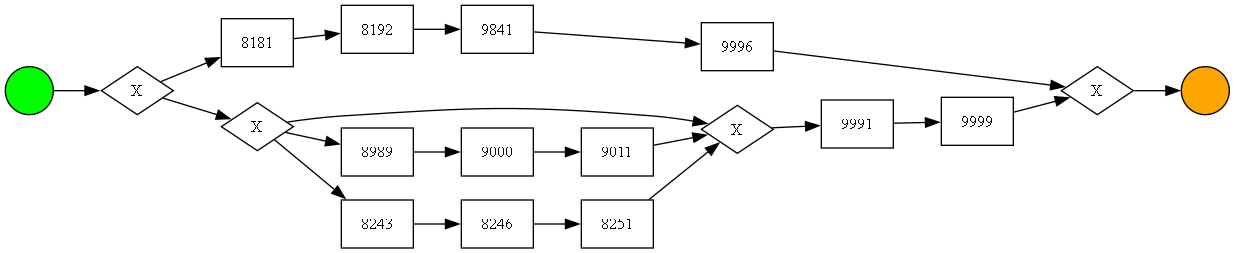


  SPUTTER_METAL_BACKSIDE  (23 traces)


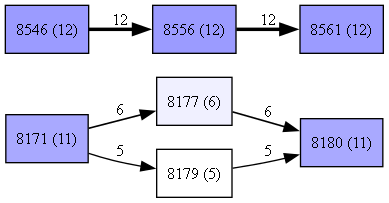

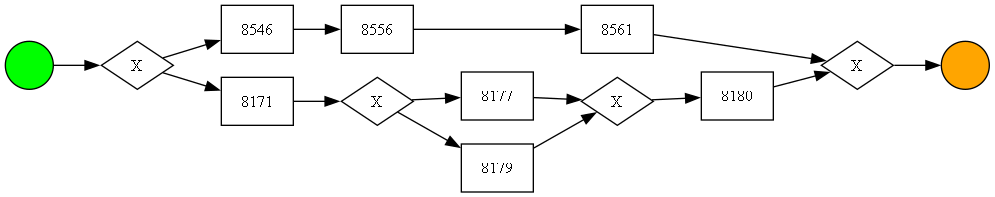


  TAIKO_GRINDING  (17 traces)


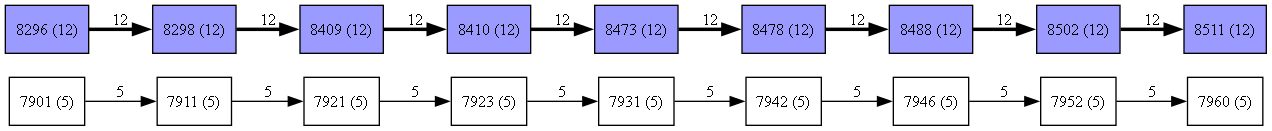

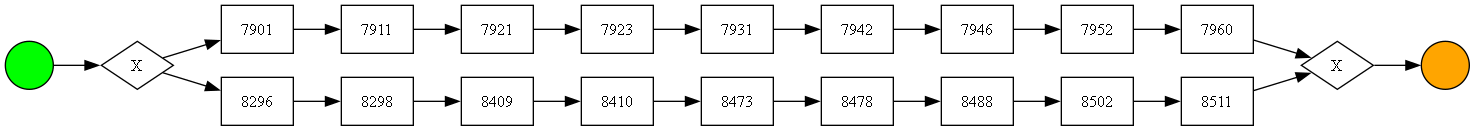

In [16]:
from pm4py.visualization.dfg import visualizer as dfg_visualizer

for family, log in logs.items():
    print(f"\n{'='*60}")
    print(f"  {family}  ({len(log)} traces)")
    print(f"{'='*60}")

    dfg, start, end = pm4py.discover_dfg(log)
    activities_count = pm4py.get_event_attribute_values(log, "concept:name")
    gviz = dfg_visualizer.apply(
        dfg, activities_count=activities_count,
        variant=dfg_visualizer.Variants.FREQUENCY,
    )
    dfg_visualizer.view(gviz)

    bpmn = pm4py.discover_bpmn_inductive(log)
    pm4py.view_bpmn(bpmn)

## Summary

In [17]:
print(f"Generated {len(logs)} directed graphs and BPMN models:")
for family, log in logs.items():
    print(f"  {family}: {len(log)} traces")

Generated 7 directed graphs and BPMN models:
  BACKSIDE_IMPLANT: 23 traces
  GC_DEMOUNT: 17 traces
  GC_MOUNT: 23 traces
  GRINDING: 6 traces
  LOGISTICS: 23 traces
  SPUTTER_METAL_BACKSIDE: 23 traces
  TAIKO_GRINDING: 17 traces
